# Confusion Matrix and Threshold Tuning

## Objective
Analyze classification predictions using a confusion matrix and investigate how changing the classification threshold affects precision and recall.

## Dataset
Breast Cancer Wisconsin Diagnostic Dataset

## Model
Logistic Regression

## Key Concepts
- Confusion Matrix
- True Positive
- True Negative
- False Positive
- False Negative
- Precision
- Recall
- F1 Score
- Probability Threshold
- Threshold Tuning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    precision_recall_curve
)

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
data = load_breast_cancer(as_frame=True)

X = data.data
original_y = data.target

print("Dataset loaded successfully!")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("\nTarget classes:")
print(data.target_names)

Dataset loaded successfully!
Number of samples: 569
Number of features: 30

Target classes:
['malignant' 'benign']


In [3]:
# Convert target so that:
# 0 = Benign
# 1 = Malignant

y = (original_y == 0).astype(int)

print("Target distribution:")
print(pd.Series(y).value_counts())

print("\n0 = Benign")
print("1 = Malignant")

Target distribution:
target
0    357
1    212
Name: count, dtype: int64

0 = Benign
1 = Malignant


In [4]:
print("Dataset shape:", X.shape)

print("\nFirst 5 rows:")
display(X.head())

print("\nMissing values:")
print(X.isnull().sum().sum())

print("\nClass distribution:")
print(
    pd.Series(y)
    .map({0: "Benign", 1: "Malignant"})
    .value_counts()
)

Dataset shape: (569, 30)

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Missing values:
0

Class distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64


In [5]:
print("Dataset shape:", X.shape)

print("\nFirst 5 rows:")
display(X.head())

print("\nMissing values:")
print(X.isnull().sum().sum())

print("\nClass distribution:")
print(
    pd.Series(y)
    .map({0: "Benign", 1: "Malignant"})
    .value_counts()
)

Dataset shape: (569, 30)

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Missing values:
0

Class distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [7]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=5000))
])

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [8]:
y_pred_05 = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_05)
precision = precision_score(y_test, y_pred_05)
recall = recall_score(y_test, y_pred_05)
f1 = f1_score(y_test, y_pred_05)

print("Results at default threshold = 0.5")
print("-----------------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Results at default threshold = 0.5
-----------------------------------
Accuracy : 0.9649
Precision: 0.975
Recall   : 0.9286
F1 Score : 0.9512


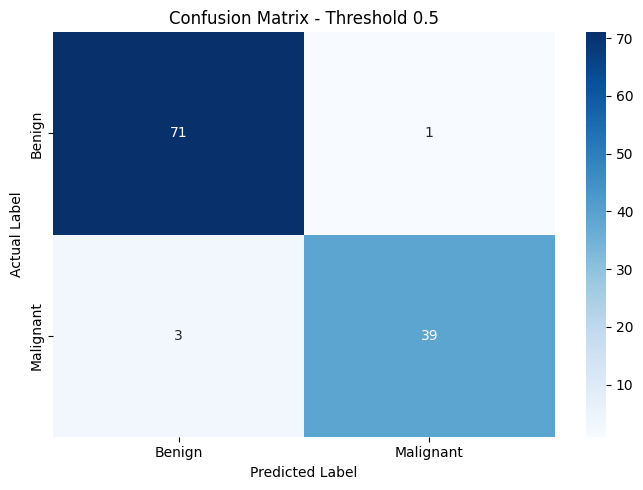

In [9]:
cm = confusion_matrix(y_test, y_pred_05)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Threshold 0.5")

plt.tight_layout()
plt.show()

In [10]:
y_probability = model.predict_proba(X_test)[:, 1]

print("First 10 predicted probabilities:")
print(y_probability[:10])

First 10 predicted probabilities:
[3.64568116e-04 9.99999989e-01 4.25679471e-02 5.76187322e-01
 5.09155489e-01 6.16001620e-04 7.61534086e-01 1.01217174e-03
 5.68725516e-04 1.07675795e-02]


In [11]:
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

results = []

for threshold in thresholds:

    y_pred_threshold = (y_probability >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_test,
        y_pred_threshold
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

results_df = pd.DataFrame(results)

display(results_df.round(4))

,Threshold,Accuracy,Precision,Recall,F1 Score,TN,FP,FN,TP
0,0.2,0.9561,0.9111,0.9762,0.9425,68,4,1,41
1,0.3,0.9825,0.9762,0.9762,0.9762,71,1,1,41
2,0.4,0.9737,0.9756,0.9524,0.9639,71,1,2,40
3,0.5,0.9649,0.9750,0.9286,0.9512,71,1,3,39
4,0.6,0.9649,1.0000,0.9048,0.9500,72,0,4,38
5,0.7,0.9649,1.0000,0.9048,0.9500,72,0,4,38
6,0.8,0.9474,1.0000,0.8571,0.9231,72,0,6,36


In [12]:
results_df.to_csv(
    "threshold_results.csv",
    index=False
)

print("threshold_results.csv saved successfully!")

threshold_results.csv saved successfully!


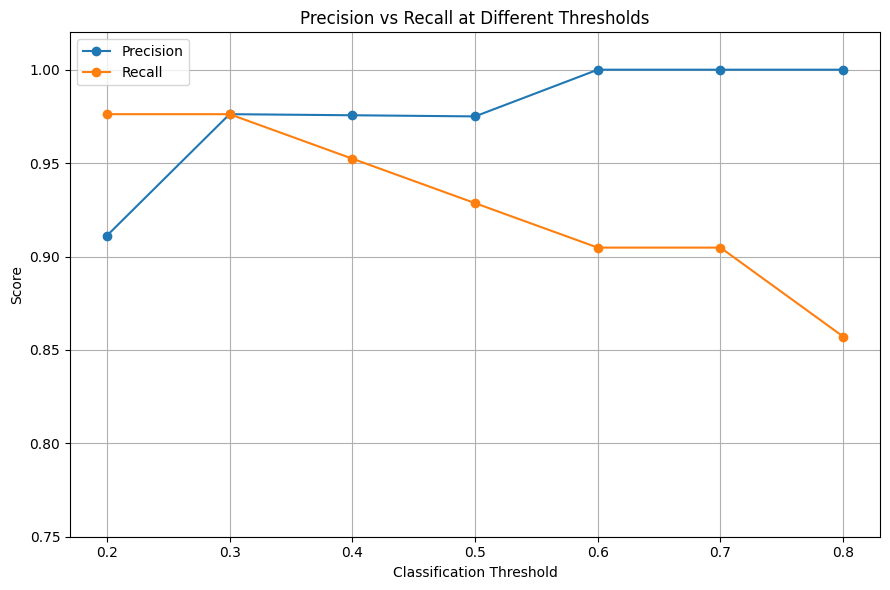

In [13]:
plt.figure(figsize=(9, 6))

plt.plot(
    results_df["Threshold"],
    results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    results_df["Threshold"],
    results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall at Different Thresholds")
plt.xticks(thresholds)
plt.ylim(0.75, 1.02)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

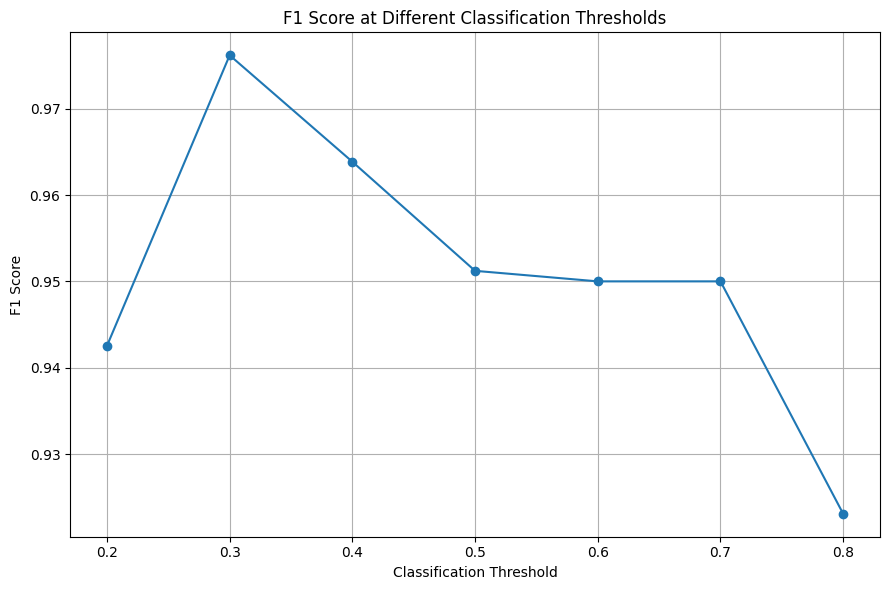

In [14]:
plt.figure(figsize=(9, 6))

plt.plot(
    results_df["Threshold"],
    results_df["F1 Score"],
    marker="o"
)

plt.xlabel("Classification Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score at Different Classification Thresholds")
plt.xticks(thresholds)
plt.grid(True)

plt.tight_layout()
plt.show()

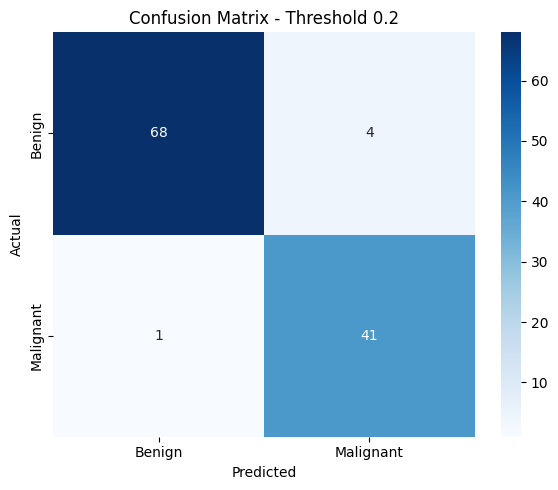

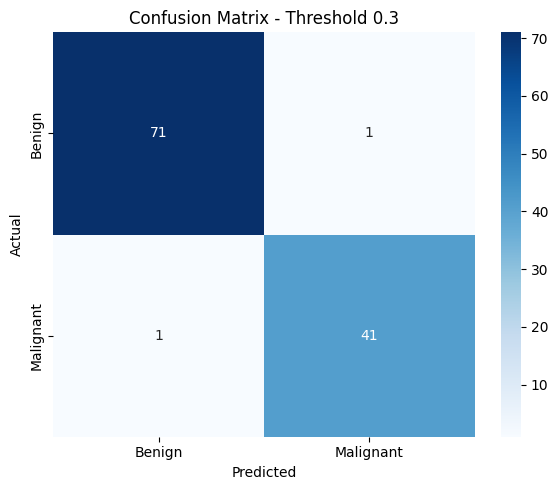

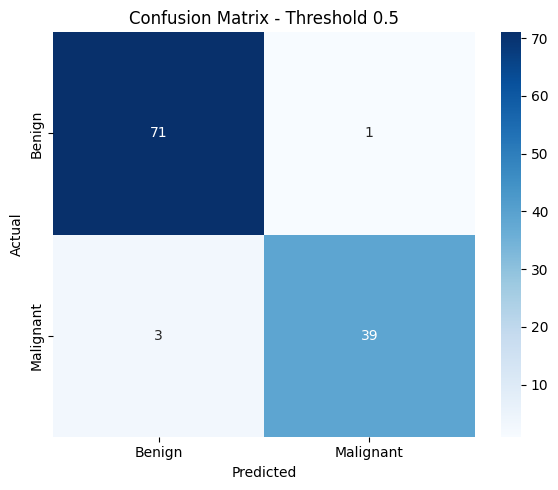

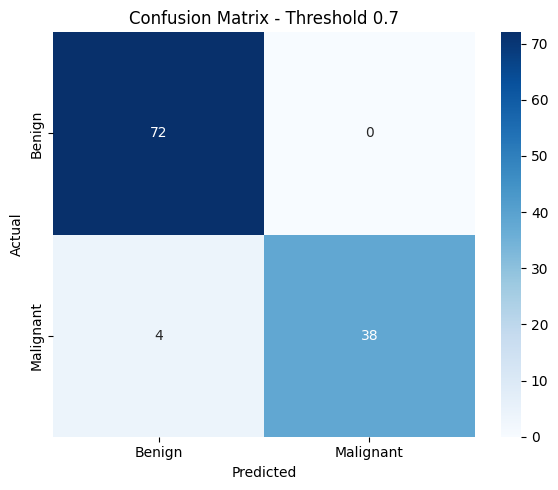

In [15]:
selected_thresholds = [0.20, 0.30, 0.50, 0.70]

for threshold in selected_thresholds:

    y_pred_threshold = (y_probability >= threshold).astype(int)

    cm = confusion_matrix(
        y_test,
        y_pred_threshold
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Benign", "Malignant"],
        yticklabels=["Benign", "Malignant"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - Threshold {threshold}")

    plt.tight_layout()
    plt.show()

In [16]:
minimum_recall = 0.95

eligible_thresholds = results_df[
    results_df["Recall"] >= minimum_recall
]

if len(eligible_thresholds) > 0:

    recommended_row = eligible_thresholds.loc[
        eligible_thresholds["Precision"].idxmax()
    ]

    print("Recommended Threshold:")
    print("----------------------")
    print("Threshold :", recommended_row["Threshold"])
    print("Precision :", round(recommended_row["Precision"], 4))
    print("Recall    :", round(recommended_row["Recall"], 4))
    print("F1 Score  :", round(recommended_row["F1 Score"], 4))

else:

    recommended_row = results_df.loc[
        results_df["F1 Score"].idxmax()
    ]

    print("No threshold achieved the required recall.")
    print("Using the threshold with maximum F1 score instead.")

    print("\nRecommended Threshold:")
    print("----------------------")
    print("Threshold :", recommended_row["Threshold"])
    print("Precision :", round(recommended_row["Precision"], 4))
    print("Recall    :", round(recommended_row["Recall"], 4))
    print("F1 Score  :", round(recommended_row["F1 Score"], 4))

Recommended Threshold:
----------------------
Threshold : 0.3
Precision : 0.9762
Recall    : 0.9762
F1 Score  : 0.9762


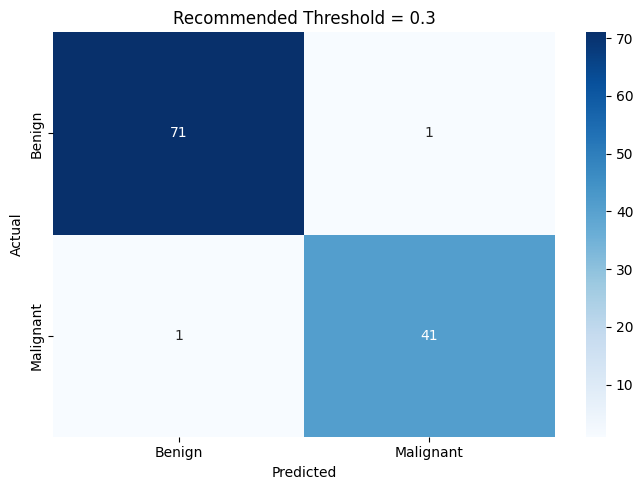

In [17]:
recommended_threshold = recommended_row["Threshold"]

y_pred_recommended = (
    y_probability >= recommended_threshold
).astype(int)

cm_recommended = confusion_matrix(
    y_test,
    y_pred_recommended
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_recommended,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    f"Recommended Threshold = {recommended_threshold}"
)

plt.tight_layout()
plt.show()

In [18]:
print(
    classification_report(
        y_test,
        y_pred_recommended,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99        72
   Malignant       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



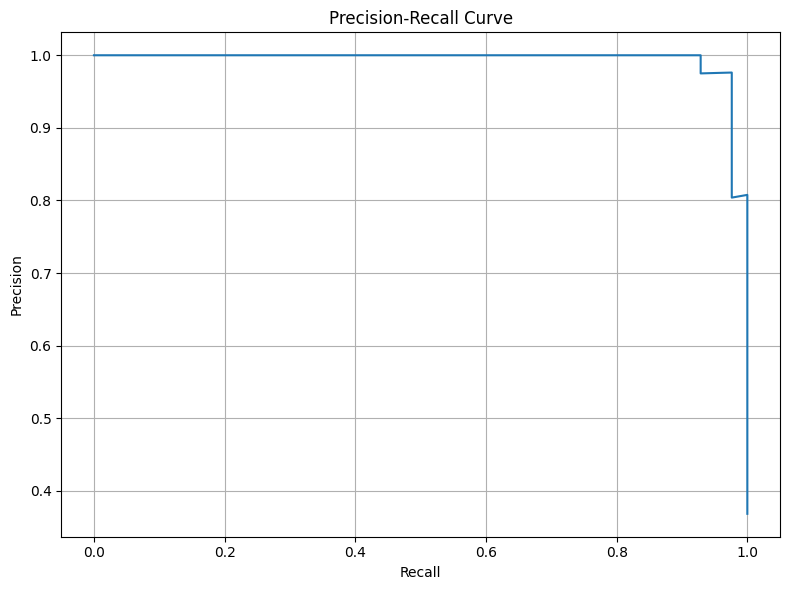

In [19]:
precision_values, recall_values, pr_thresholds = precision_recall_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
# Save the threshold table
results_df.to_csv(
    "threshold_results.csv",
    index=False
)

# Save final predictions
prediction_output = pd.DataFrame({
    "Actual": y_test.values,
    "Probability_Malignant": y_probability,
    "Predicted_Default_0.5": y_pred_05,
    "Predicted_Recommended": y_pred_recommended
})

prediction_output.to_csv(
    "predictions.csv",
    index=False
)

print("Files saved:")
print("1. threshold_results.csv")
print("2. predictions.csv")

Files saved:
1. threshold_results.csv
2. predictions.csv


In [21]:
plt.savefig("precision_recall_threshold.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>